In [1]:
# Control-composition sensitivity review (Moore et al. Batch_1)
# Reads only what run_control_composition*.py already wrote to Analysis_Results/Control_Composition/
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, '..')
from viz_style import apply_style
apply_style()
import config

res = pd.read_csv(config.CTRL_COMP_DIR / 'jaccard_results.csv')
null = pd.read_csv(config.CTRL_COMP_DIR / 'null_distribution.csv')
print(f"tertile rows: {len(res)}, null rows: {len(null)}")
res.head()

tertile rows: 198, null rows: 3600


,jaccard_k25,signflip_k25,jaccard_k50,signflip_k50,jaccard_k100,signflip_k100,jaccard_k200,signflip_k200,jaccard_k500,signflip_k500,spearman,disease,split,axis,draw,tag,layer,n_case,n_ctrl,delta_d
0,0.000000,NaN,0.003367,0.0,0.011810,0.0,0.016994,0.0,0.038521,0.0,0.305712,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,CPM_log1p,72,23.0,2.358629
1,0.000000,NaN,0.006803,0.0,0.016990,0.0,0.023964,0.0,0.043509,0.0,0.304923,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,TPM_log2,72,23.0,2.358629
2,0.000000,NaN,0.000000,NaN,0.006734,0.0,0.012714,0.0,0.035703,0.0,0.312630,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,TMM_log2,72,23.0,2.358629
3,0.006803,0.0,0.010309,0.0,0.013765,0.0,0.026848,0.0,0.050207,0.0,0.351389,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,RUVg_Platelet_k1,72,23.0,2.358629
4,0.000000,NaN,0.000000,NaN,0.015281,0.0,0.023103,0.0,0.046259,0.0,0.367063,Pancreatic Cancer,tertile,log(Total Reads),-1,Pancreatic_Cancer__log_Total_Reads,RUVg_Platelet_k2,72,23.0,2.358629


In [2]:
# 1. null p-value per (disease, layer, axis): how often a size-matched random split
# agrees no better than the bias-stratified split
def null_pvalue(res, null, metric='jaccard_k100'):
    out = []
    for (dis, lay), g in null.groupby(['disease', 'layer']):
        ref = g[metric].values
        for _, r in res[(res.disease == dis) & (res.layer == lay)].iterrows():
            out.append(dict(disease=dis, layer=lay, axis=r['axis'], obs=r[metric],
                            null_mean=float(ref.mean()), null_sd=float(ref.std()),
                            p_lower=float((ref <= r[metric]).mean())))
    return pd.DataFrame(out)

pval = null_pvalue(res, null)
pval.sort_values('p_lower').head(20)

,disease,layer,axis,obs,null_mean,null_sd,p_lower
10,Pancreatic Cancer,CPM_log1p,PC1_bias,0.005025,0.023329,0.005815,0.0
54,Pancreatic Cancer,RUVg_Platelet_k1,PC1_bias,0.005042,0.020579,0.005450,0.0
99,Pancreatitis,CPM_log1p,log(Total Reads),0.005042,0.016057,0.005157,0.0
100,Pancreatitis,CPM_log1p,Spliced Reads (%),0.005042,0.016057,0.005157,0.0
87,Pancreatic Cancer,TMM_log2,PC1_bias,0.003350,0.020098,0.005317,0.0
109,Pancreatitis,CPM_log1p,PC1_bias,0.001675,0.016057,0.005157,0.0
105,Pancreatitis,CPM_log1p,GC Bias,0.005042,0.016057,0.005157,0.0
110,Pancreatitis,Proposed_Full_k1,log(Total Reads),0.000000,0.012523,0.004666,0.0
96,Pancreatic Cancer,TPM_log2,NG80,0.008547,0.025642,0.006303,0.0
98,Pancreatic Cancer,TPM_log2,PC1_bias,0.003350,0.025642,0.006303,0.0


In [3]:
# p_lower = fraction of null (random-split) jaccard_k100 draws <= the observed tertile value,
# per (disease, layer); low p_lower = tertile reproduces WORSE than a same-size random split.
print(f"null baseline jaccard@100: mean={null['jaccard_k100'].mean():.3f}, "
     f"sd={null['jaccard_k100'].std():.3f}  (tier 1 floor, axis-independent)")
print(f"tertile vs null: median p_lower={pval['p_lower'].median():.3f}, "
     f"{(pval['p_lower'] < 0.05).mean()*100:.0f}% of (disease,layer,axis) significantly BELOW null, "
     f"{(pval['p_lower'] > 0.95).mean()*100:.0f}% significantly ABOVE null")

by_axis = pval.groupby('axis')['p_lower'].agg(
    median_p_lower='median',
    frac_sig_worse=lambda s: (s < 0.05).mean(),
    frac_sig_better=lambda s: (s > 0.95).mean()).sort_values('median_p_lower')
by_axis['frac_sig_worse'] = (by_axis['frac_sig_worse'] * 100).round(1).astype(str) + '%'
by_axis['frac_sig_better'] = (by_axis['frac_sig_better'] * 100).round(1).astype(str) + '%'
by_axis

null baseline jaccard@100: mean=0.018, sd=0.007  (tier 1 floor, axis-independent)
tertile vs null: median p_lower=0.075, 43% of (disease,layer,axis) significantly BELOW null, 2% significantly ABOVE null


,median_p_lower,frac_sig_worse,frac_sig_better
axis,,,
PC1_bias,0.0025,77.8%,0.0%
NG80,0.0150,66.7%,0.0%
log(Total Reads),0.0175,72.2%,0.0%
Gene Length Bias,0.0550,50.0%,0.0%
GC Bias,0.0550,44.4%,0.0%
gDNA Contamination (Intron/Exon),0.0650,44.4%,0.0%
RNA Degradation (3' Bias),0.1000,27.8%,0.0%
Spliced Reads (%),0.1050,38.9%,0.0%
Platelet Score,0.1175,38.9%,22.2%


In [4]:
# 3. optional deep dive into one comparison's t-statistics / expression matrices
# (written per-comparison by run_control_composition.py; load only what's needed)
tag = 'Pancreatic_Cancer__PC1_bias'
stat_dir = config.CTRL_COMP_STAT_DIR / tag
t0 = pd.read_csv(stat_dir / 'T0_welch_t.csv.gz', index_col=0)
t2 = pd.read_csv(stat_dir / 'T2_welch_t.csv.gz', index_col=0)
t0[['CPM_log1p', 'GeneName']].join(t2[['CPM_log1p']], rsuffix='_T2').sort_values('CPM_log1p').head(10)

,CPM_log1p,GeneName,CPM_log1p_T2
ENSG00000107223.14,-3.507659,EDF1,0.407309
ENSG00000124228.16,-3.502703,DDX27,1.032138
ENSG00000114861.25,-3.281962,FOXP1,-2.319043
ENSG00000242028.9,-3.106850,HYPK,0.329804
ENSG00000136802.13,-3.087232,LRRC8A,-2.334358
ENSG00000213741.12,-3.076732,RPS29,0.170255
ENSG00000116251.12,-3.042118,RPL22,0.670042
ENSG00000133106.16,-3.015448,EPSTI1,1.189197
ENSG00000100941.10,-2.949856,PNN,1.648041
ENSG00000142541.19,-2.931174,RPL13A,-0.202351


In [5]:
# 4. DESeq2 arm (run_control_composition_deseq2.py): same tags/subsets, Wald `stat` instead
# of Welch t. 2 designs only (no_covariate, ruvg_k2) and a smaller null (n=30 vs 200) --
# see script docstring for the runtime tradeoff.
d_res = pd.read_csv(config.CTRL_COMP_DIR / 'deseq2_jaccard_results.csv')
d_null = pd.read_csv(config.CTRL_COMP_DIR / 'deseq2_null_distribution.csv')
d_pval = null_pvalue(d_res, d_null)
print(f"tertile rows: {len(d_res)}, null rows: {len(d_null)}")
d_pval.sort_values('p_lower').head(20)

tertile rows: 44, null rows: 120


,disease,layer,axis,obs,null_mean,null_sd,p_lower
1,Pancreatic Cancer,no_covariate,Spliced Reads (%),0.058364,0.086005,0.010683,0.000000
7,Pancreatic Cancer,no_covariate,Gene Length Bias,0.039718,0.086005,0.010683,0.000000
5,Pancreatic Cancer,no_covariate,Platelet Score,0.036317,0.086005,0.010683,0.000000
4,Pancreatic Cancer,no_covariate,RNA Degradation (3' Bias),0.051026,0.086005,0.010683,0.000000
10,Pancreatic Cancer,no_covariate,PC1_bias,0.053537,0.086005,0.010683,0.000000
13,Pancreatic Cancer,ruvg_k2,gDNA Contamination (Intron/Exon),0.119115,0.148169,0.013428,0.000000
8,Pancreatic Cancer,no_covariate,NG80,0.056944,0.086005,0.010683,0.000000
16,Pancreatic Cancer,ruvg_k2,Platelet Score,0.114041,0.148169,0.013428,0.000000
21,Pancreatic Cancer,ruvg_k2,PC1_bias,0.104793,0.148169,0.013428,0.000000
23,Pancreatitis,no_covariate,Spliced Reads (%),0.011845,0.031693,0.008413,0.000000


In [6]:
# same null-vs-tertile test as cell 3, DESeq2 arm (see that cell's comment for how p_lower is defined)
print(f"tertile vs null (DESeq2): median p_lower={d_pval['p_lower'].median():.3f}, "
     f"{(d_pval['p_lower'] < 0.05).mean()*100:.0f}% of (disease,layer,axis) significantly BELOW null, "
     f"{(d_pval['p_lower'] > 0.95).mean()*100:.0f}% significantly ABOVE null")

d_by_axis = d_pval.groupby('axis')['p_lower'].agg(
    median_p_lower='median',
    frac_sig_worse=lambda s: (s < 0.05).mean(),
    frac_sig_better=lambda s: (s > 0.95).mean()).sort_values('median_p_lower')
d_by_axis['frac_sig_worse'] = (d_by_axis['frac_sig_worse'] * 100).round(1).astype(str) + '%'
d_by_axis['frac_sig_better'] = (d_by_axis['frac_sig_better'] * 100).round(1).astype(str) + '%'
d_by_axis

tertile vs null (DESeq2): median p_lower=0.050, 50% of (disease,layer,axis) significantly BELOW null, 5% significantly ABOVE null


,median_p_lower,frac_sig_worse,frac_sig_better
axis,,,
RNA Degradation (3' Bias),0.000000,75.0%,0.0%
PC1_bias,0.000000,75.0%,0.0%
Gene Length Bias,0.016667,75.0%,0.0%
Platelet Score,0.016667,75.0%,0.0%
NG80,0.033333,50.0%,0.0%
log(Total Reads),0.033333,75.0%,0.0%
GC Bias,0.133333,25.0%,0.0%
rRNA Fraction,0.200000,25.0%,0.0%
Spliced Reads (%),0.266667,50.0%,0.0%


25320 rows (422 tags x 5 layers x 9 K)


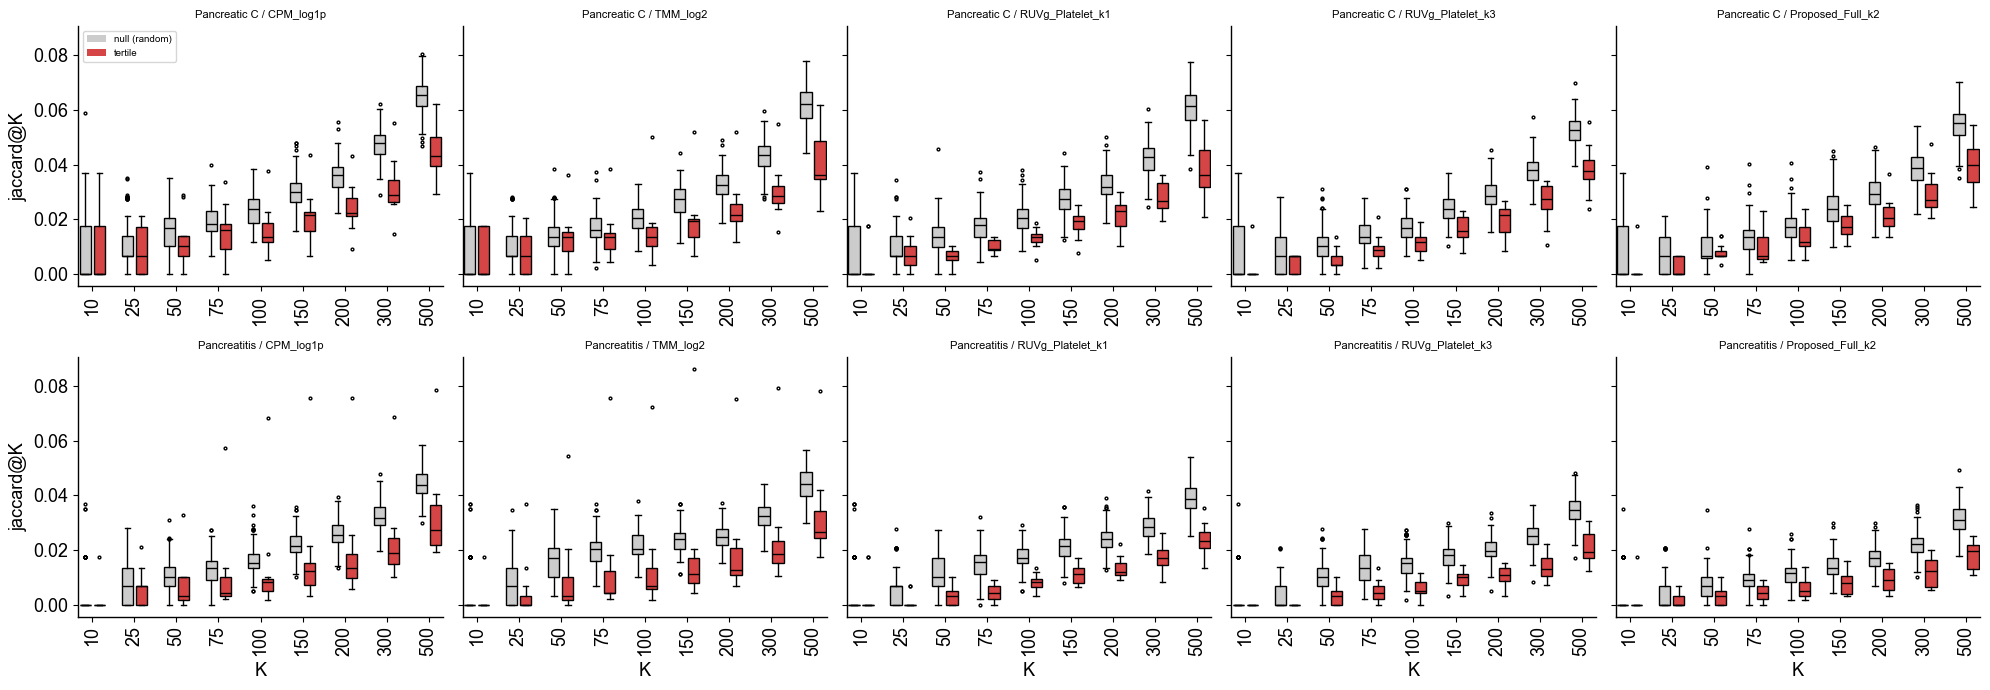

In [7]:
EXT_K_GRID = [10, 25, 50, 75, 100, 150, 200, 300, 500]
EXT_CACHE = config.CTRL_COMP_DIR / 'jaccard_extended_k.pkl'
layers_show = ['CPM_log1p', 'TMM_log2', 'RUVg_Platelet_k1', 'RUVg_Platelet_k3', 'Proposed_Full_k2']

def jaccard_at_k(ti, tj, k):
    a = set(np.argsort(-np.abs(ti))[:k])
    b = set(np.argsort(-np.abs(tj))[:k])
    return len(a & b) / len(a | b)

def tag_jaccard(tag, layers, k_grid):
    dfs = [pd.read_csv(config.CTRL_COMP_STAT_DIR / tag / f'T{t}_welch_t.csv.gz', index_col=0)[layers]
          for t in range(3)]
    rows = []
    for i in range(3):
        for j in range(i + 1, 3):
            for l in layers:
                ti, tj = dfs[i][l].values, dfs[j][l].values
                for k in k_grid:
                    rows.append(dict(layer=l, k=k, jaccard=jaccard_at_k(ti, tj, k)))
    return pd.DataFrame(rows).groupby(['layer', 'k'])['jaccard'].mean().reset_index()

if EXT_CACHE.exists():
    ext = pd.read_pickle(EXT_CACHE)
else:
    rows = []
    tags = pd.concat([res[['disease', 'split', 'tag']], null[['disease', 'split', 'tag']]]).drop_duplicates('tag')
    for _, row in tags.iterrows():
        g = tag_jaccard(row['tag'], layers_show, EXT_K_GRID)
        g['disease'], g['split'], g['tag'] = row['disease'], row['split'], row['tag']
        rows.append(g)
    ext = pd.concat(rows, ignore_index=True)
    ext.to_pickle(EXT_CACHE)
print(f"{len(ext)} rows ({ext['tag'].nunique()} tags x {len(layers_show)} layers x {len(EXT_K_GRID)} K)")

def plot_jaccard_k_box(ext, disease, layer, ax, k_grid=EXT_K_GRID):
    null_med, tert_med = [], []
    sub = ext[(ext.disease == disease) & (ext.layer == layer)]
    for i, k in enumerate(k_grid):
        nv = sub[(sub.split == 'random') & (sub.k == k)]['jaccard'].values
        rv = sub[(sub.split == 'tertile') & (sub.k == k)]['jaccard'].values
        ax.boxplot([nv], positions=[i * 3], widths=0.8, patch_artist=True,
                  boxprops=dict(facecolor='#cccccc'), medianprops=dict(color='black'), flierprops=dict(markersize=2))
        ax.boxplot([rv], positions=[i * 3 + 1], widths=0.8, patch_artist=True,
                  boxprops=dict(facecolor='#d64545'), medianprops=dict(color='black'), flierprops=dict(markersize=2))
        null_med.append(np.median(nv)); tert_med.append(np.median(rv))
    # x_null = [i * 3 for i in range(len(k_grid))]
    # x_tert = [i * 3 + 1 for i in range(len(k_grid))]
    # ax.plot(x_null, null_med, '-', color='#888888', lw=1.2, zorder=0)
    # ax.plot(x_tert, tert_med, '-', color='#d64545', lw=1.2, zorder=0)
    ax.set_xticks([i * 3 + 0.5 for i in range(len(k_grid))])
    ax.set_xticklabels(k_grid, rotation=90)

fig, axes = plt.subplots(2, len(layers_show), figsize=(4 * len(layers_show), 7), sharey=True)
for row, disease in enumerate(ext['disease'].unique()):
    for col, layer in enumerate(layers_show):
        plot_jaccard_k_box(ext, disease, layer, axes[row, col])
        axes[row, col].set_title(f'{disease[:12]} / {layer}', fontsize=8)
        if row == 1: axes[row, col].set_xlabel('K')
axes[0, 0].set_ylabel('jaccard@K')
axes[1, 0].set_ylabel('jaccard@K')

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in ['#cccccc', '#d64545']]
axes[0, 0].legend(handles, ['null (random)', 'tertile'], fontsize=7, loc='upper left')

plt.tight_layout()
config.CTRL_COMP_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.CTRL_COMP_FIG_DIR / 'jaccard_k_boxplot.png', dpi=150)
plt.show()

1968 rows (82 tags x 2 designs x 9 K)


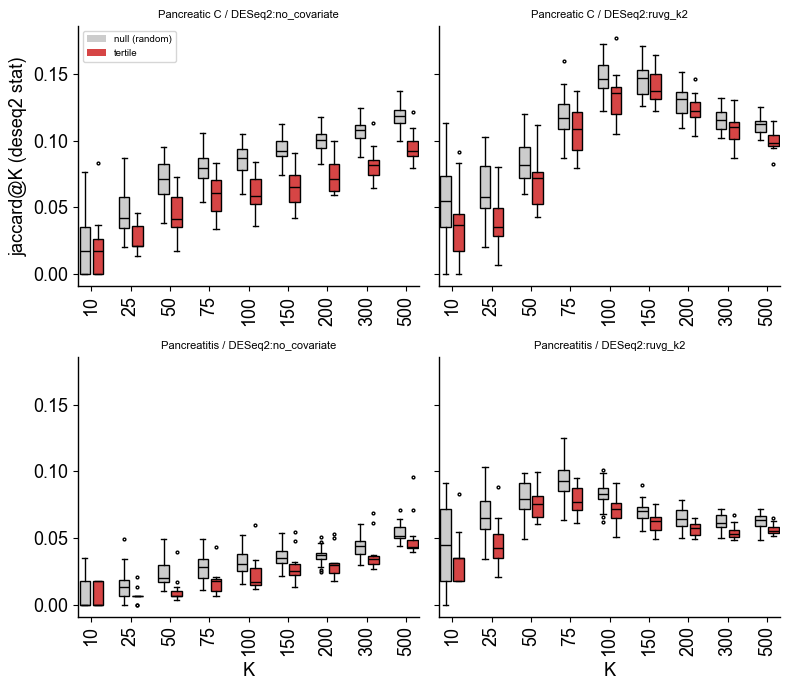

In [8]:
# 6. same boxplot+trend, DESeq2 arm. Files are one column ('stat') per (tag, stratum,
# design) rather than all layers in one file, so the reader differs; jaccard_at_k /
# plot_jaccard_k_box from cell 5 are reused as-is.
DESEQ2_DESIGNS = ['no_covariate', 'ruvg_k2']
D_EXT_CACHE = config.CTRL_COMP_DIR / 'deseq2_jaccard_extended_k.pkl'

def tag_jaccard_deseq2(tag, designs, k_grid):
    rows = []
    for i in range(3):
        for j in range(i + 1, 3):
            for d in designs:
                ti = pd.read_csv(config.CTRL_COMP_DESEQ2_DIR / tag / f'T{i}_{d}.csv.gz', index_col=0)['stat'].values
                tj = pd.read_csv(config.CTRL_COMP_DESEQ2_DIR / tag / f'T{j}_{d}.csv.gz', index_col=0)['stat'].values
                for k in k_grid:
                    rows.append(dict(layer=d, k=k, jaccard=jaccard_at_k(ti, tj, k)))
    return pd.DataFrame(rows).groupby(['layer', 'k'])['jaccard'].mean().reset_index()

if D_EXT_CACHE.exists():
    d_ext = pd.read_pickle(D_EXT_CACHE)
else:
    rows = []
    tags = pd.concat([d_res[['disease', 'split', 'tag']], d_null[['disease', 'split', 'tag']]]).drop_duplicates('tag')
    for _, row in tags.iterrows():
        g = tag_jaccard_deseq2(row['tag'], DESEQ2_DESIGNS, EXT_K_GRID)
        g['disease'], g['split'], g['tag'] = row['disease'], row['split'], row['tag']
        rows.append(g)
    d_ext = pd.concat(rows, ignore_index=True)
    d_ext.to_pickle(D_EXT_CACHE)
print(f"{len(d_ext)} rows ({d_ext['tag'].nunique()} tags x {len(DESEQ2_DESIGNS)} designs x {len(EXT_K_GRID)} K)")

fig, axes = plt.subplots(2, len(DESEQ2_DESIGNS), figsize=(4 * len(DESEQ2_DESIGNS), 7), sharey=True)
for row, disease in enumerate(d_ext['disease'].unique()):
    for col, design in enumerate(DESEQ2_DESIGNS):
        plot_jaccard_k_box(d_ext, disease, design, axes[row, col])
        axes[row, col].set_title(f'{disease[:12]} / DESeq2:{design}', fontsize=8)
        if row == 1: axes[row, col].set_xlabel('K')
axes[0, 0].set_ylabel('jaccard@K (deseq2 stat)')
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in ['#cccccc', '#d64545']]
axes[0, 0].legend(handles, ['null (random)', 'tertile'], fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(config.CTRL_COMP_FIG_DIR / 'deseq2_jaccard_k_boxplot.png', dpi=150)
plt.show()

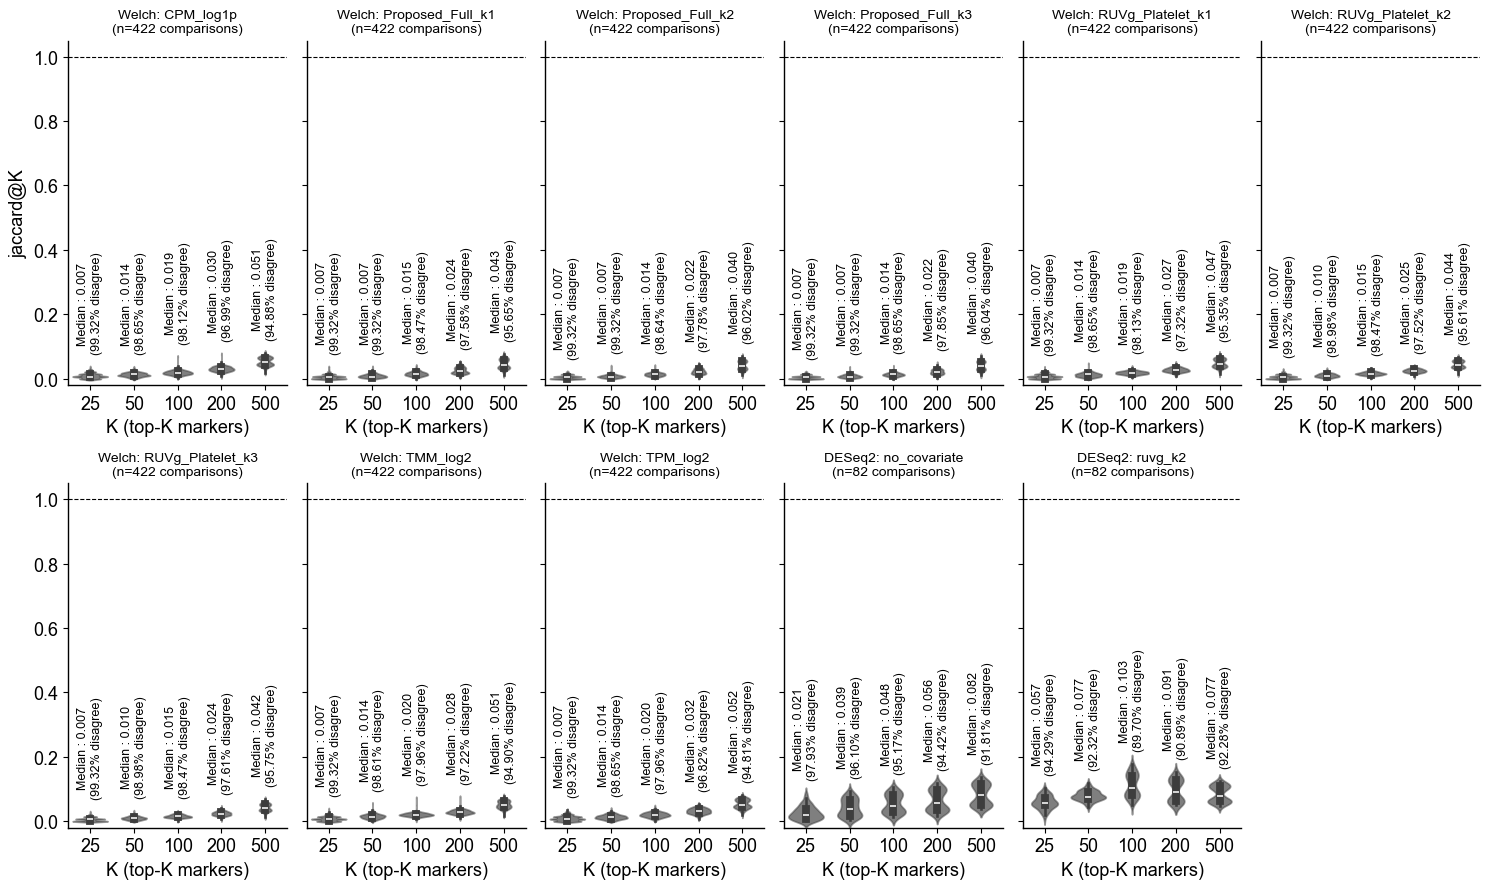

In [9]:
import seaborn as sns
K_SHOW = [25, 50, 100, 200, 500]

def plot_headline(ax, allc, title):
    data = [allc[f'jaccard_k{k}'].dropna().values for k in K_SHOW]
    sns.violinplot(
    ax=ax,
    data=data,
    color="black",
    inner="box",
    alpha=0.5,
    )
    for i, k in enumerate(K_SHOW):
        med, mx = np.median(data[i]), data[i].max()
        ax.text(i, mx + 0.05, f"Median : {med:.3f}\n({(1 - med) * 100:.2f}% disagree)", ha='center', fontsize=9, rotation=90)
    ax.axhline(1.0, color='black', ls='--', lw=0.8)
    ax.set_xticks(range(len(K_SHOW))); ax.set_xticklabels(K_SHOW)
    ax.set_xlabel('K (top-K markers)')
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(f'{title}\n(n={allc["tag"].nunique()} comparisons)', fontsize=10)

allc_welch = pd.concat([res.assign(split='tertile'), null.assign(split='random')], ignore_index=True)
allc_deseq2 = pd.concat([d_res.assign(split='tertile'), d_null.assign(split='random')], ignore_index=True)

# every condition at once: 9 Welch-t layers + 2 DESeq2 designs, one panel each
conditions = [(allc_welch[allc_welch.layer == l], f'Welch: {l}') for l in sorted(allc_welch['layer'].unique())]
conditions += [(allc_deseq2[allc_deseq2.layer == d], f'DESeq2: {d}') for d in sorted(allc_deseq2['layer'].unique())]

n_cols = 6
n_rows = int(np.ceil(len(conditions) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.5 * n_cols, 4.5 * n_rows), sharey=True)
axes = axes.flatten()
for ax, (df, title) in zip(axes, conditions):
    plot_headline(ax, df, title)
for ax in axes[len(conditions):]:
    ax.axis('off')
axes[0].set_ylabel('jaccard@K')
plt.tight_layout()
plt.savefig(config.CTRL_COMP_FIG_DIR / 'headline_jaccard_floor_all_conditions.png', dpi=150)
plt.show()

In [10]:
gsea_summary = pd.read_csv(config.CTRL_COMP_DIR / 'gsea_split_jaccard' / 'summary.csv')
gsea_deseq2 = gsea_summary[gsea_summary['method'].str.startswith('deseq2')]
print(f"{len(gsea_deseq2)} (axis, design) rows")
# detail (per-split full GSEA table, e.g. NES/FDR per pathway) for one condition:
# pd.read_csv(config.CTRL_COMP_DIR / 'gsea_split_jaccard' / 'detail' /
#             'Pancreatic_Cancer__PC1_bias__deseq2__ruvg_k2__T0.csv.gz')

import pickle
nm_sig = pickle.load(open(config.ROOT / 'MixedEffectsModeling' / 'PathwayConvergence' /
                          'Pancreatic_Cancer' / 'sig.pkl', 'rb'))
gene_sig, path_sig, terms = nm_sig['gene_sig'], nm_sig['path_sig'], nm_sig['terms']
print(f"NM baseline: {gene_sig.shape[0]} patients, {gene_sig.shape[1]} genes, {path_sig.shape[1]} pathways")

22 (axis, design) rows
NM baseline: 72 patients, 19858 genes, 2063 pathways


In [11]:
gsea_deseq2

,tag,axis,method,n_sig_T0,n_sig_T1,n_sig_T2,jacc_T0T1,jacc_T0T2,jacc_T1T2,jacc_mean
4,Pancreatic_Cancer__GC_Bias,GC_Bias,deseq2__no_covariate,27,69,99,0.170732,0.135135,0.135135,0.147001
5,Pancreatic_Cancer__GC_Bias,GC_Bias,deseq2__ruvg_k2,0,29,32,0.000000,0.000000,0.016667,0.005556
10,Pancreatic_Cancer__Gene_Length_Bias,Gene_Length_Bias,deseq2__no_covariate,52,86,161,0.053435,0.109375,0.216749,0.126520
11,Pancreatic_Cancer__Gene_Length_Bias,Gene_Length_Bias,deseq2__ruvg_k2,0,21,7,0.000000,0.000000,0.166667,0.055556
16,Pancreatic_Cancer__NG80,NG80,deseq2__no_covariate,10,53,287,0.145455,0.031250,0.129568,0.102091
17,Pancreatic_Cancer__NG80,NG80,deseq2__ruvg_k2,0,6,12,0.000000,0.000000,0.000000,0.000000
22,Pancreatic_Cancer__NP80_NG80,NP80_NG80,deseq2__no_covariate,181,119,3,0.293103,0.016575,0.008264,0.105981
23,Pancreatic_Cancer__NP80_NG80,NP80_NG80,deseq2__ruvg_k2,29,29,2,0.208333,0.000000,0.000000,0.069444
27,Pancreatic_Cancer__PC1_bias,PC1_bias,deseq2__no_covariate,35,72,139,0.019048,0.144737,0.241176,0.134987
28,Pancreatic_Cancer__PC1_bias,PC1_bias,deseq2__ruvg_k2,0,17,3,0.000000,0.000000,0.052632,0.017544


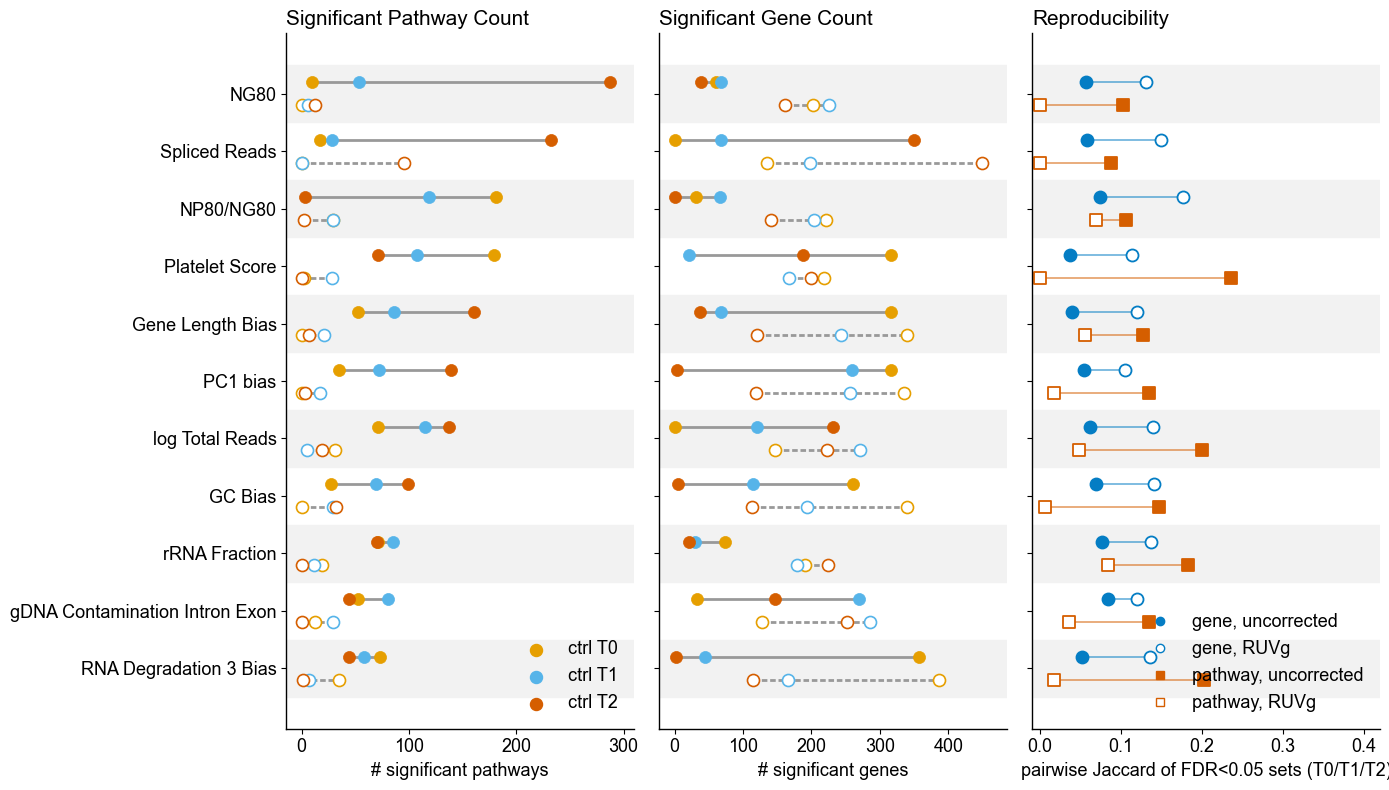

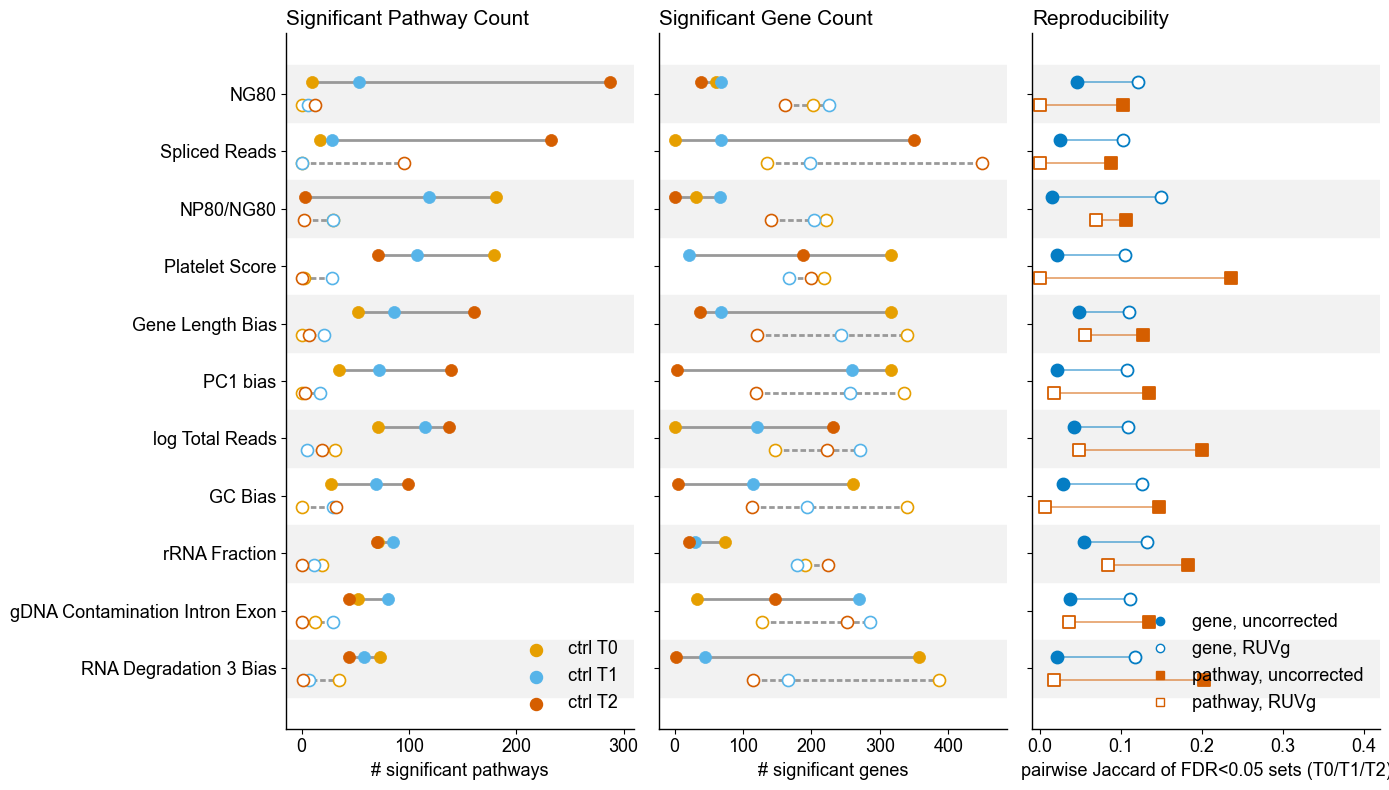

In [12]:
# 8. headline figure: gene- and pathway-level, uncorrected and RUVg-corrected, all in one view.
from scipy.stats import norm
from string import ascii_uppercase

def bh_fdr_reject(p, q=0.05):
    p = np.asarray(p)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] <= (np.arange(1, n + 1) / n) * q
    if not ranked.any():
        return np.zeros(n, dtype=bool)
    k_max = np.max(np.where(ranked)[0])
    reject = np.zeros(n, dtype=bool)
    reject[order[:k_max + 1]] = True
    return reject

def pretty_axis(a):
    if a == 'NP80_NG80':
        return 'NP80/NG80'
    return a.replace('__', ' ').replace('_', ' ')

OKABE = {'T0': '#E69F00', 'T1': '#56B4E9', 'T2': '#D55E00'}
DESIGN_STYLE = {'no_covariate': dict(ls='-', marker_face=True, label='uncorrected'),
               'ruvg_k2': dict(ls=(0, (2, 1)), marker_face=False, label='RUVg-corrected')}

AXIS_MAP = {
    'GC Bias': 'GC_Bias', 'Gene Length Bias': 'Gene_Length_Bias', 'NG80': 'NG80',
    '(NP80/NG80)': 'NP80_NG80', 'PC1_bias': 'PC1_bias', 'Platelet Score': 'Platelet_Score',
    "RNA Degradation (3' Bias)": 'RNA_Degradation__3__Bias', 'Spliced Reads (%)': 'Spliced_Reads',
    'gDNA Contamination (Intron/Exon)': 'gDNA_Contamination__Intron_Exon',
    'log(Total Reads)': 'log_Total_Reads', 'rRNA Fraction': 'rRNA_Fraction',
}
# Two gene-level reproducibility definitions, plotted as two otherwise identical figures.
#   top100 -- fixed-size lists, immune to set-size drift, but hides it
#   fdr    -- the set a paper would actually report; shrinks when set sizes swing too
gene_j_top100 = d_res[(d_res.disease == 'Pancreatic Cancer') & (d_res.layer.isin(DESEQ2_DESIGNS))].copy()
gene_j_top100['axis_slug'] = gene_j_top100['axis'].map(AXIS_MAP)
gene_j_top100 = gene_j_top100.set_index(['axis_slug', 'layer'])['jaccard_k100']

sys.path.insert(0, str(Path.cwd() / 'control_composition'))
from compute_fdr_set_jaccard import load as load_fdr_jaccard
fdr_j = load_fdr_jaccard()
gene_j_fdr = (fdr_j[(fdr_j.disease == 'Pancreatic Cancer') & (fdr_j.kind == 'tertile')]
              .set_index(['axis', 'design'])['jaccard_fdr'])

GENE_JACC = {'top100': (gene_j_top100, 'pairwise Jaccard, top-100 DE genes', (-0.03, 1.08), True),
             'fdr': (gene_j_fdr, 'pairwise Jaccard, FDR<0.05 DE sets', (-0.01, 0.42), False)}

path_all = gsea_deseq2.copy()
path_all['design'] = path_all['method'].str.replace('deseq2__', '', regex=False)
for d in DESEQ2_DESIGNS:
    sub = path_all[path_all.design == d].set_index('axis')
    path_all.loc[path_all.design == d, 'n_min'] = sub[['n_sig_T0', 'n_sig_T1', 'n_sig_T2']].min(axis=1).values
    path_all.loc[path_all.design == d, 'n_max'] = sub[['n_sig_T0', 'n_sig_T1', 'n_sig_T2']].max(axis=1).values
path_all = path_all.set_index(['axis', 'design'])

nocov_order = path_all.xs('no_covariate', level='design').sort_values('n_max').index.tolist()
y = np.arange(len(nocov_order))

GENE_NSIG_CACHE = config.CTRL_COMP_DIR / 'gene_nsig_cache.csv'
if GENE_NSIG_CACHE.exists():
    gene_n_all = pd.read_csv(GENE_NSIG_CACHE).set_index(['axis', 'design'])
else:
    rows = []
    for a_human, a_slug in AXIS_MAP.items():
        tag = f'Pancreatic_Cancer__{a_slug}'
        d_stat_dir = config.CTRL_COMP_DESEQ2_DIR / tag
        for design in DESEQ2_DESIGNS:
            n_sig = {}
            for i in range(3):
                stat = pd.read_csv(d_stat_dir / f'T{i}_{design}.csv.gz', index_col=0)['stat'].dropna()
                p = 2 * norm.sf(np.abs(stat.values))
                n_sig[f'n_sig_T{i}'] = int(bh_fdr_reject(p, q=0.05).sum())
            rows.append(dict(axis=a_slug, design=design, **n_sig))
    gene_n_all = pd.DataFrame(rows)
    gene_n_all.to_csv(GENE_NSIG_CACHE, index=False)
    gene_n_all = gene_n_all.set_index(['axis', 'design'])
gene_n_all['n_min'] = gene_n_all[['n_sig_T0', 'n_sig_T1', 'n_sig_T2']].min(axis=1)
gene_n_all['n_max'] = gene_n_all[['n_sig_T0', 'n_sig_T1', 'n_sig_T2']].max(axis=1)

for _key, (gene_j_all, _xlab, _xlim, _show_one) in GENE_JACC.items():
 fig, (axP, axG, axJ) = plt.subplots(1, 3, figsize=(14, 8), sharey=True)

 def shade_rows(ax):
     for i in range(len(nocov_order)):
         if i % 2 == 0:
             ax.axhspan(i - 0.5, i + 0.5, color='#f2f2f2', zorder=0)

 def plot_nsig_panel(ax, n_all, xlabel, title):
     shade_rows(ax)
     for i, a in enumerate(nocov_order):
         for off, design in zip([0.20, -0.20], DESEQ2_DESIGNS):
             row = n_all.loc[(a, design)]
             st = DESIGN_STYLE[design]
             ax.plot([row.n_min, row.n_max], [i + off, i + off], color='#999999', lw=2, ls=st['ls'], zorder=1)
             for split, c in OKABE.items():
                 ax.scatter(row[f'n_sig_{split}'], i + off, s=75, zorder=2,
                           facecolor=c if st['marker_face'] else 'white',
                           edgecolors=c, linewidths=1.2 if not st['marker_face'] else 0.5)
     ax.set_xlabel(xlabel)
     ax.set_title(title, loc='left')
     ax.set_xlim(-n_all.n_max.max() * 0.05, n_all.n_max.max() * 1.08)

 axP.set_yticks(y); axP.set_yticklabels([pretty_axis(a) for a in nocov_order])

 plot_nsig_panel(axP, path_all, '# significant pathways', 'Significant Pathway Count')
 for c, lab in OKABE.items():
     axP.scatter([], [], color=lab, s=75, label=f'ctrl {c}')
 axP.legend(loc='lower right', frameon=False)

 plot_nsig_panel(axG, gene_n_all, '# significant genes', 'Significant Gene Count')

 # --- gene and pathway Jaccard on separate tracks, each showing uncorrected -> RUVg ---
 shade_rows(axJ)
 LEVEL_STYLE = {'gene': dict(marker='o', color='#047DC4', off=0.20), 'pathway': dict(marker='s', color='#D55E00', off=-0.20)}
 for i, a in enumerate(nocov_order):
     for level, jac_lookup in [('gene', gene_j_all), ('pathway', path_all['jacc_mean'])]:
         st = LEVEL_STYLE[level]
         yy = i + st['off']
         vals = {design: jac_lookup.get((a, design), np.nan) for design in DESEQ2_DESIGNS}
         axJ.plot([vals['no_covariate'], vals['ruvg_k2']], [yy, yy], color=st['color'], lw=1.2, zorder=1, alpha=0.6)
         for design in DESEQ2_DESIGNS:
             filled = DESIGN_STYLE[design]['marker_face']
             axJ.scatter(vals[design], yy, s=75, marker=st['marker'], zorder=2,
                        facecolor=st['color'] if filled else 'white',
                        edgecolor=st['color'], linewidths=1.3)
 axJ.set_xlabel('pairwise Jaccard of FDR<0.05 sets (T0/T1/T2)')
 axJ.set_title('Reproducibility', loc='left')
 axJ.set_xlim(-0.01, 0.42)
 legend_handles = [
     plt.Line2D([], [], marker='o', color='#047DC4', linestyle='', markerfacecolor="#047DC4", label='gene, uncorrected'),
     plt.Line2D([], [], marker='o', color='#047DC4', linestyle='', markerfacecolor='white', label='gene, RUVg'),
     plt.Line2D([], [], marker='s', color='#D55E00', linestyle='', markerfacecolor='#D55E00', label='pathway, uncorrected'),
     plt.Line2D([], [], marker='s', color='#D55E00', linestyle='', markerfacecolor='white', label='pathway, RUVg'),
 ]
 axJ.legend(handles=legend_handles, loc='lower right', frameon=False)

 plt.tight_layout()
 plt.savefig(config.CTRL_COMP_FIG_DIR / f'group_comparison_instability_headline_{_key}.png', dpi=150, bbox_inches='tight')
 plt.show()

null_vs_tertile_jaccard_top100.png no_covariate   random 0.0860  tertile 0.0601  axes below random mean: 11/11
null_vs_tertile_jaccard_top100.png ruvg_k2        random 0.1482  tertile 0.1333  axes below random mean: 9/11


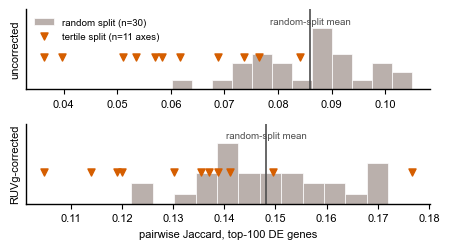

null_vs_tertile_jaccard_fdr.png no_covariate   random 0.0362  tertile 0.0323  axes below random mean: 6/11
null_vs_tertile_jaccard_fdr.png ruvg_k2        random 0.1329  tertile 0.1173  axes below random mean: 10/11


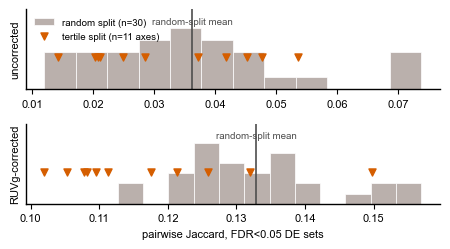

In [13]:
# 9. null control: structured (tertile) vs size-matched random splits of the same HC pool.
# Same figure twice: fixed top-100 lists, and the FDR<0.05 significant sets.
def plot_null_vs_tertile(get_vals, xlabel, out_name, logx=False):
    fig, axes = plt.subplots(len(DESEQ2_DESIGNS), 1, figsize=(4.6, 2.6))
    for i, (ax, design) in enumerate(zip(np.atleast_1d(axes), DESEQ2_DESIGNS)):
        nv, tv = get_vals(design)
        lo, hi = min(nv.min(), tv.min()), max(nv.max(), tv.max())
        bins = np.logspace(np.log10(lo), np.log10(hi), 13) if logx else 12
        ax.hist(nv, bins=bins, color='#BAB0AC', edgecolor='white', linewidth=0.5,
                label=f'random split (n={len(nv)})')
        if logx:
            ax.set_xscale('log')
        top = ax.get_ylim()[1]
        ax.axvline(nv.mean(), color='#4E4E4E', lw=1.2)
        ax.text(nv.mean(), top * 1.02, 'random-split mean', fontsize=7, color='#4E4E4E', ha='center')
        ax.scatter(tv, np.full(len(tv), top * 0.5), s=26, marker='v', color='#D55E00', zorder=3,
                   label=f'tertile split (n={len(tv)} axes)')
        ax.set_ylim(0, top * 1.25)
        ax.set_ylabel(DESIGN_STYLE[design]['label'], fontsize=8)
        ax.set_yticks([]); ax.tick_params(labelsize=8, which='both')
        if i == 0:
            ax.legend(loc='upper left', frameon=False, fontsize=7)
        print(f'{out_name:>10s} {design:14s} random {nv.mean():.4f}  tertile {tv.mean():.4f}  '
              f'axes below random mean: {(tv < nv.mean()).sum()}/{len(tv)}')
    np.atleast_1d(axes)[-1].set_xlabel(xlabel, fontsize=8)
    plt.tight_layout()
    plt.savefig(config.CTRL_COMP_FIG_DIR / out_name, dpi=300, bbox_inches='tight')
    plt.show()

def _top100(design):
    q = "disease == 'Pancreatic Cancer' and layer == @design"
    return (d_null.query(q)['jaccard_k100'], d_res.query(q)['jaccard_k100'])

def _fdr(design):
    pc = fdr_j[(fdr_j.disease == 'Pancreatic Cancer') & (fdr_j.design == design)]
    return (pc.loc[pc.kind == 'random', 'jaccard_fdr'], pc.loc[pc.kind == 'tertile', 'jaccard_fdr'])

plot_null_vs_tertile(_top100, 'pairwise Jaccard, top-100 DE genes', 'null_vs_tertile_jaccard_top100.png')
plot_null_vs_tertile(_fdr, 'pairwise Jaccard, FDR<0.05 DE sets', 'null_vs_tertile_jaccard_fdr.png')


nsig_set_size_instability.png no_covariate   random 13.5310  tertile 90.4804  axes below random mean: 4/11
nsig_set_size_instability.png ruvg_k2        random 1.5460  tertile 2.2728  axes below random mean: 3/11


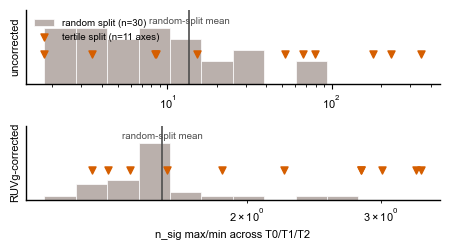

In [14]:
# 10. set-size instability: how many genes clear FDR<0.05 at all. Fixed top-k hides this
# by construction; on the FDR set it is part of why the Jaccard drops.
def _fold(design):
    pc = fdr_j[(fdr_j.disease == 'Pancreatic Cancer') & (fdr_j.design == design)].copy()
    pc['fold'] = pc.n_sig_max / pc.n_sig_min.clip(lower=1)
    return (pc.loc[pc.kind == 'random', 'fold'], pc.loc[pc.kind == 'tertile', 'fold'])

plot_null_vs_tertile(_fold, 'n_sig max/min across T0/T1/T2', 'nsig_set_size_instability.png', logx=True)
